# Run New Snow Simulation (No Past Video)

This notebook runs a new simulation from source code, saves new outputs, and visualizes generated frames.
It does not read screenshots or frames from historical videos.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('/workspaces/SnowSimulation')
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

OUT = ROOT / 'video_output' / 'new_run_results'
OUT.mkdir(parents=True, exist_ok=True)
np.random.seed(42)

print('Workspace:', ROOT)
print('Output dir:', OUT)

Workspace: /workspaces/SnowSimulation
Output dir: /workspaces/SnowSimulation/video_output/new_run_results


In [2]:
import warp as wp
from simulation.constants import SIM_DEVICE
from simulation.grid import Grid
from simulation.mpm_solver import MPMSolver
from simulation.snow_object import SnowObject, create_particle_system

wp.init()
print('Warp version:', wp.__version__)
print('Selected simulation device:', SIM_DEVICE)

Warp 1.4.2 initialized:
   CUDA Toolkit 12.6, Driver 0.0 (insufficient CUDA driver version!)
   Devices:
     "cpu"      : "x86_64"
   Kernel cache:
     /home/codespace/.cache/warp/1.4.2
Warp UserWarning: 
   Insufficient CUDA driver version.
   The minimum required CUDA driver version is 12.0, but the installed CUDA driver version is 0.0.
   Visit https://github.com/NVIDIA/warp/blob/main/README.md#installing for guidance.
Warp version: 1.4.2
Selected simulation device: cpu


Warp CUDA error: Could not open libcuda.so.
Warp CUDA error: Function cuDriverGetVersion_f: a suitable driver entry point was not found
Warp CUDA error 36 (in function cuda_driver_version, /builds/omniverse/warp/warp/native/warp.cu:1600)


In [18]:
# Build a lightweight scene for faster CPU/GPU execution
# Configure one body near the floor and downward velocities to show floor interaction clearly.
snow = SnowObject(particle_diameter=0.03, target_density=300)

snowball = snow.create_snowball(
    radius=0.06,
    center=[0.45, 0.30, 0.75],
    velocity=[0.0, -1.2, 0.0],
)

cube1 = snow.create_snowcube(
    side_length=0.09,
    center=[1.0, 0.145, 0.75],
    velocity=[0.0, -0.8, 0.0],
)

cube2 = snow.create_snowcube(
    side_length=0.09,
    center=[1.0, 0.44, 0.75],
    velocity=[0.0, -1.0, 0.0],
)

particle_system = create_particle_system([snowball, cube1, cube2])
grid = Grid(size=32, grid_space=0.015)
solver = MPMSolver(particle_system, grid)

print('Particle count:', particle_system.num_particles)

Particle count: 87


In [19]:
# Run simulation and capture newly generated states
# Duration is extended and still practical in CPU fallback mode.
num_steps = 160
capture_every = 20
snapshots = []
steps = []

solver.run_initial_step()
for step in range(num_steps + 1):
    if step % capture_every == 0:
        snapshots.append(solver.particle_system.positions.numpy().copy())
        steps.append(step)
    solver.run_time_step()

print('Captured snapshots:', len(snapshots))

Captured snapshots: 9


In [20]:
# Save new simulation state arrays and per-step frame images
# Style: white snow particles on dark-blue background + explicit floor line.
states_dir = OUT / 'states'
frames_dir = OUT / 'frames'
states_dir.mkdir(parents=True, exist_ok=True)
frames_dir.mkdir(parents=True, exist_ok=True)

# Remove stale files so results are from this run only.
for old_npz in states_dir.glob('*.npz'):
    old_npz.unlink()
for old_png in frames_dir.glob('*.png'):
    old_png.unlink()

saved_images = []

for idx, (step, pts) in enumerate(zip(steps, snapshots)):
    np.savez_compressed(states_dir / f'state_{idx:03d}_step_{step:03d}.npz', positions=pts, step=step)

    fig, ax = plt.subplots(figsize=(6, 6))
    dark_blue = '#0B1F5E'
    floor_y = 0.1
    fig.patch.set_facecolor(dark_blue)
    ax.set_facecolor(dark_blue)

    ax.scatter(pts[:, 0], pts[:, 1], s=10, c='white', alpha=0.95, edgecolors='none')
    ax.axhline(floor_y, color='#87CEEB', linewidth=1.2, linestyle='--', alpha=0.95)

    ax.set_xlim(0.0, 1.5)
    ax.set_ylim(0.0, 0.9)
    ax.set_title(f'New Simulation - Step {step}', color='white')
    ax.set_xlabel('x', color='white')
    ax.set_ylabel('y', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('white')
    ax.grid(alpha=0.14, color='white')

    img_path = frames_dir / f'frame_{idx:03d}_step_{step:03d}.png'
    fig.savefig(img_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    saved_images.append(img_path)

print('Saved state files:', len(list(states_dir.glob('*.npz'))))
print('Saved frame images:', len(saved_images))

Saved state files: 9
Saved frame images: 9


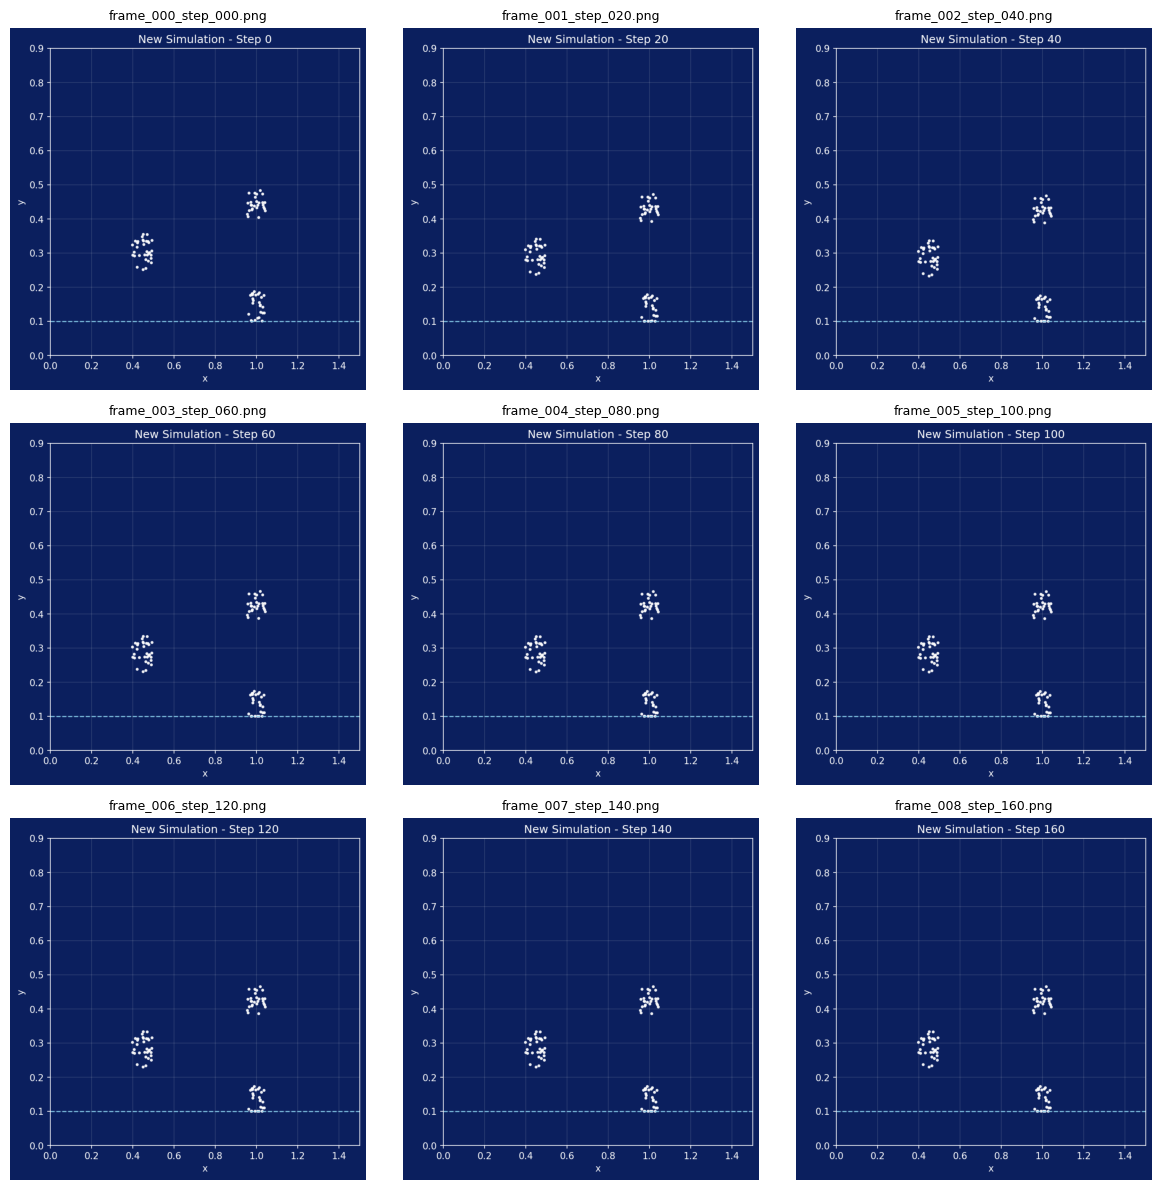

In [21]:
# Visualize the generated frame series in-grid
# Use evenly spaced sampling across the full timeline.
preview_count = min(len(saved_images), 9)
if preview_count == 0:
    raise RuntimeError('No saved images to preview.')

indices = np.linspace(0, len(saved_images) - 1, preview_count, dtype=int)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = np.array(axes).reshape(-1)

for i in range(9):
    ax = axes[i]
    if i < preview_count:
        img = plt.imread(saved_images[indices[i]])
        ax.imshow(img)
        ax.set_title(saved_images[indices[i]].name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
print('Result root:', OUT)
print('Frames directory:', frames_dir)
print('States directory:', states_dir)
print('\nSample output files:')
for p in sorted(frames_dir.glob('*.png'))[:5]:
    print('-', p.relative_to(ROOT))

Result root: /workspaces/SnowSimulation/video_output/new_run_results
Frames directory: /workspaces/SnowSimulation/video_output/new_run_results/frames
States directory: /workspaces/SnowSimulation/video_output/new_run_results/states

Sample output files:
- video_output/new_run_results/frames/frame_000_step_000.png
- video_output/new_run_results/frames/frame_001_step_020.png
- video_output/new_run_results/frames/frame_002_step_040.png
- video_output/new_run_results/frames/frame_003_step_060.png
- video_output/new_run_results/frames/frame_004_step_080.png
